# 03a — Generación de Datos Sintéticos para Data Science

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque3/03a-datos-sinteticos.ipynb)

> Este tema forma parte del **Bloque 3 — Aplicaciones**. Se recomienda
> haber completado los [Bloques 1](../bloque1/01-fundamentos.qmd) y
> [2](../bloque2/02-orquestacion.qmd) primero, especialmente [Prompt
> Engineering](../bloque2/02a-prompt-engineering.qmd).

In [1]:
!pip install -q sdv pandas matplotlib seaborn scipy openai python-dotenv

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from openai import OpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas que usan LLM mostrarán este mensaje hasta que configures la clave.")
else:
    client = OpenAI(base_url=LLM_URL, api_key=LLM_KEY)
    print("✅ Cliente OpenAI configurado.")

✅ Cliente OpenAI configurado.

## ¿Por qué datos sintéticos?

Los datos sintéticos son datos generados artificialmente que imitan las
propiedades estadísticas de datos reales **sin contener registros
reales**. En Data Science resuelven problemas concretos:

| Problema | Solución con datos sintéticos |
|------------------------------------|------------------------------------|
| **Dataset desbalanceado** (fraude 0.1%, normales 99.9%) | Generar más ejemplos de la clase minoritaria (oversampling) |
| **Dataset demasiado pequeño** para entrenar un modelo | Aumentar el dataset con muestras sintéticas verosímiles |
| **No puedes compartir datos reales** (RGPD, secrets corporativos) | Compartir datos sintéticos estadísticamente equivalentes |
| **Necesitas testear un pipeline** sin acceso a producción | Generar datos sintéticos con el mismo schema |
| **Simular escenarios** “what-if” que no existen en los datos históricos | Generar datos con distribuciones modificadas |

## Taxonomía de modelos generativos para datos tabulares

No todos los datos sintéticos se generan igual. Existe un espectro que
va desde lo más simple (prompting a un LLM) hasta lo más riguroso
(modelos generativos especializados):

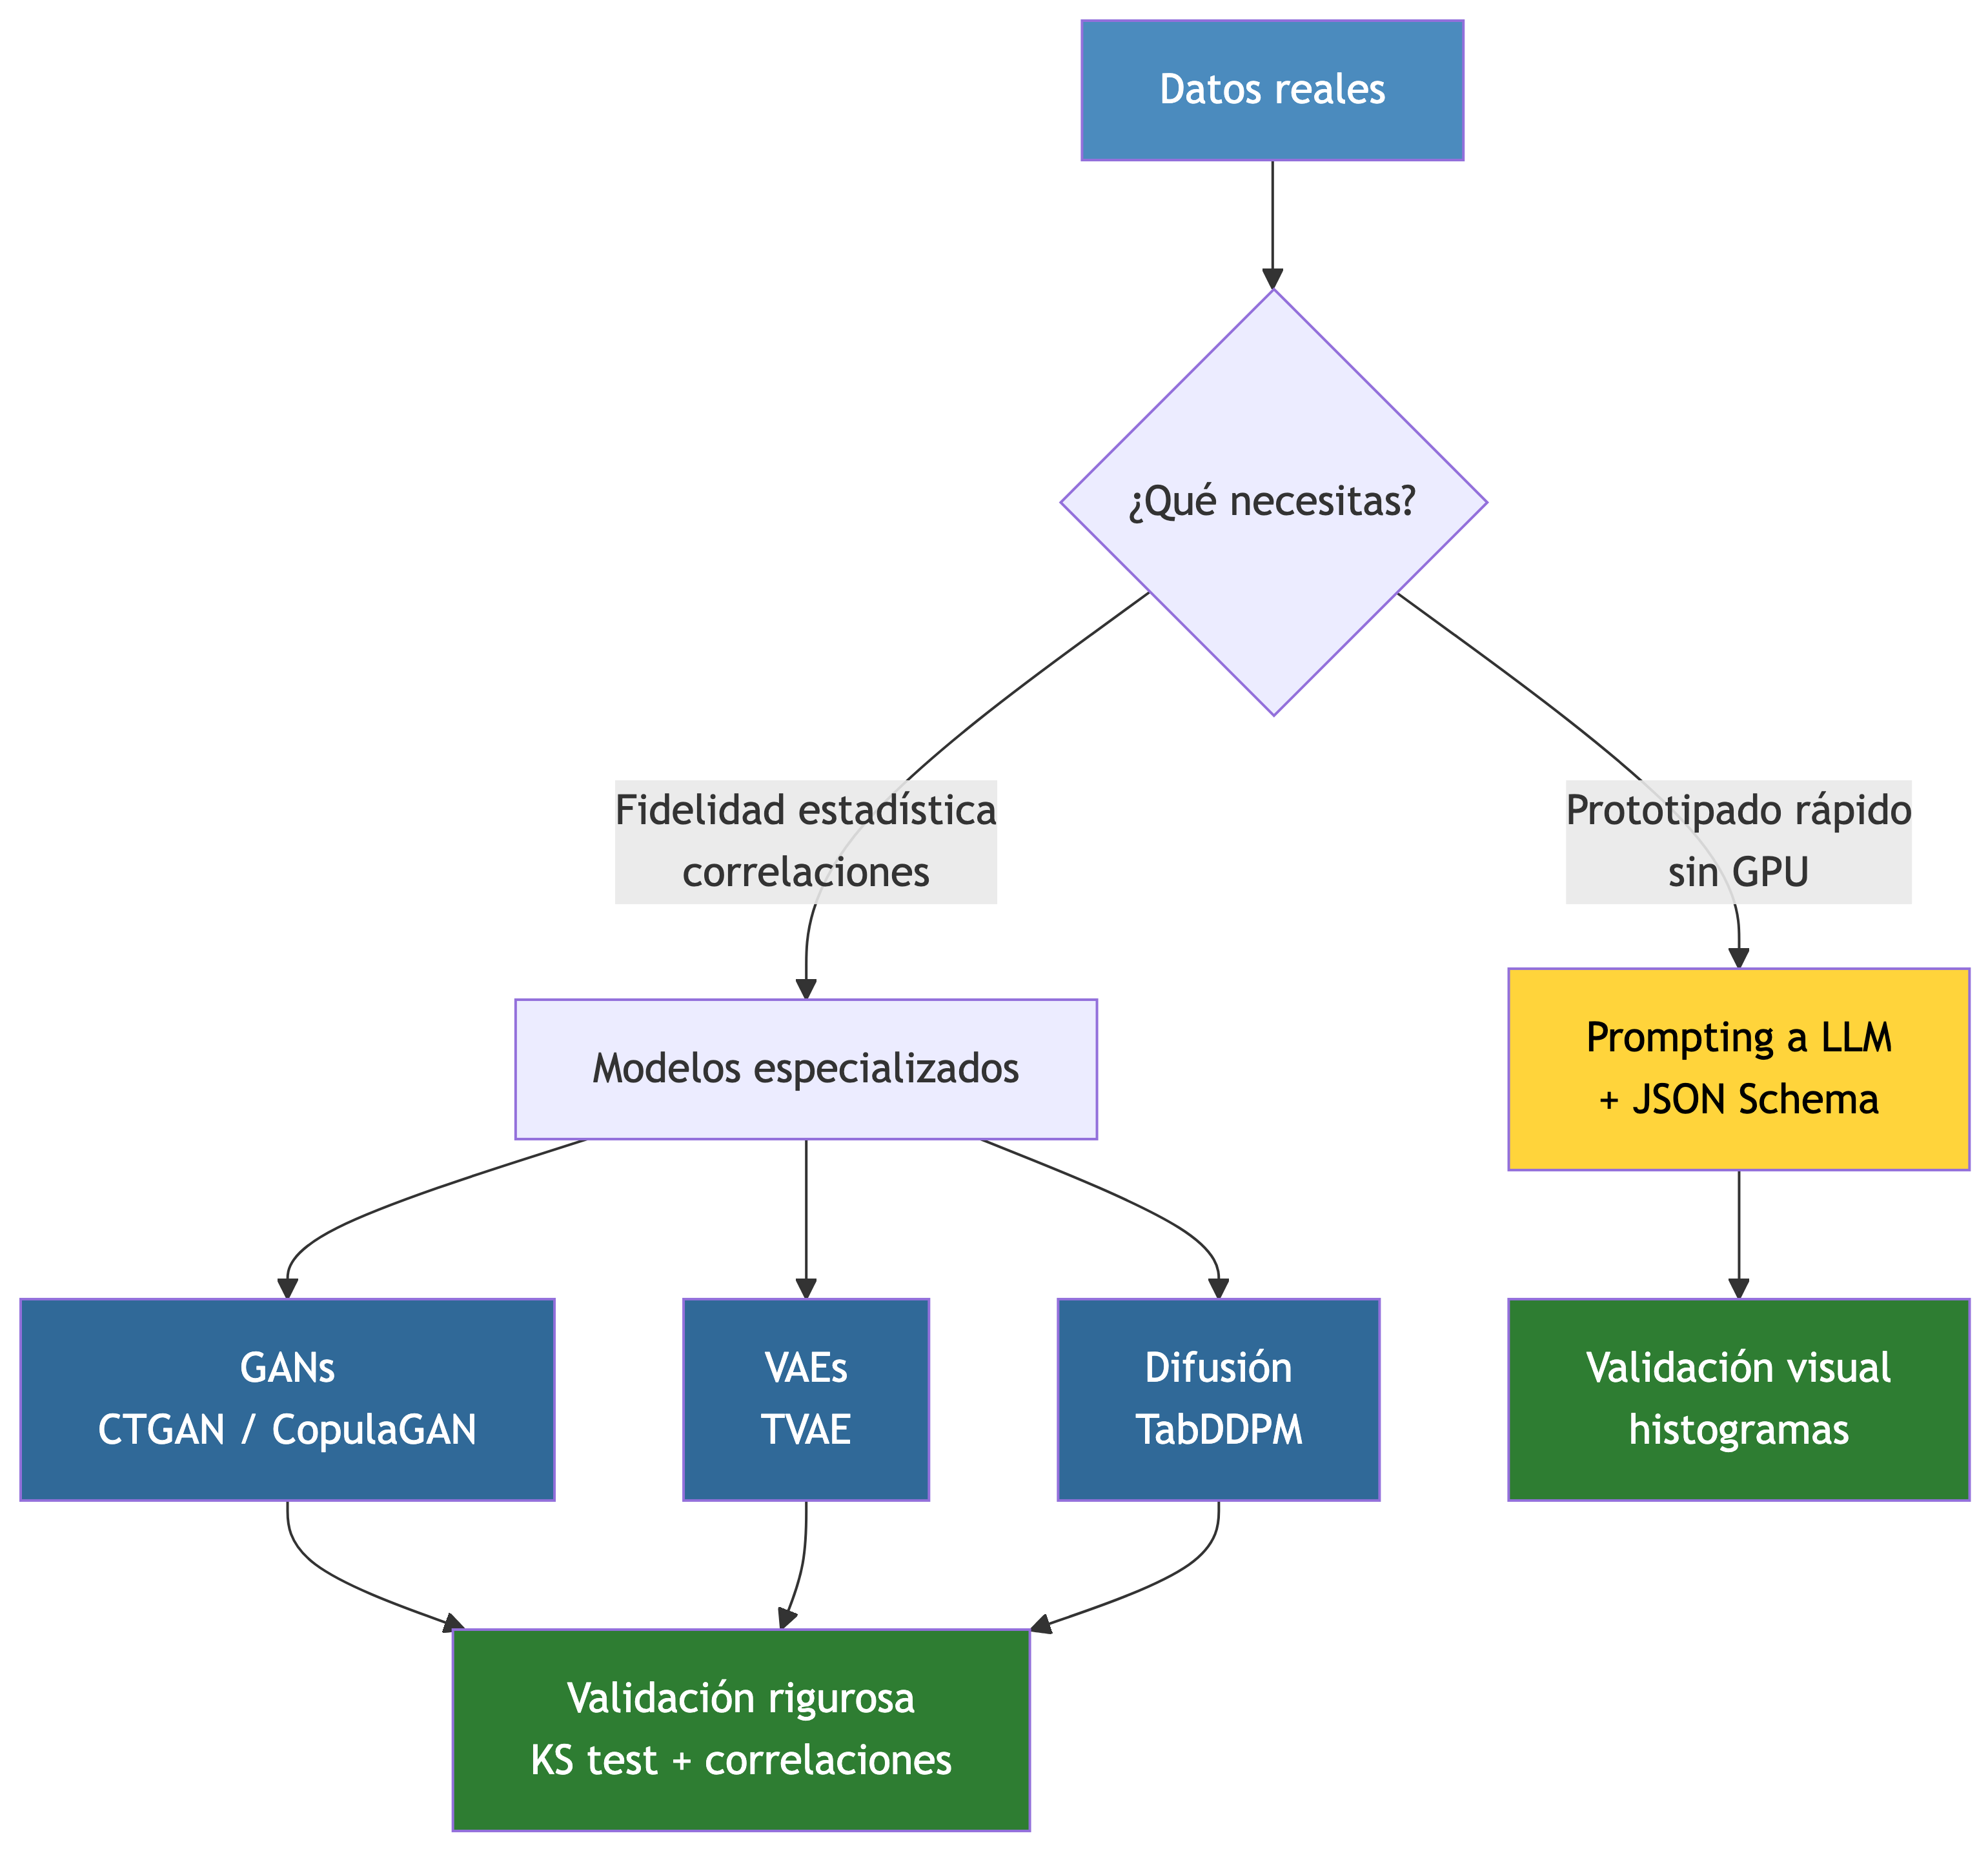

------------------------------------------------------------------------

## 1. Enfoque intuitivo: prompting a LLMs

Ya lo viste en el [Bloque 2 — Prompt
Engineering](../bloque2/02a-prompt-engineering.qmd#de-json-schema-a-datos-sintéticos-el-enfoque-intuitivo).
Con `response_format` + few-shot + temperatura controlas estructura,
dominio y diversidad.

**Fortalezas:** - Cero entrenamiento, sin GPU - Ideal para prototipos,
testing, datasets pequeños (\< 1000 filas) - Funciona especialmente bien
con datos textuales y categóricos

**Debilidades:** - No captura correlaciones complejas entre columnas
numéricas - Sin garantías de privacidad diferencial - Depende de la
calidad del prompt

------------------------------------------------------------------------

## 2. GANs para datos tabulares (CTGAN)

### Intuición: el juego del falsificador y el detective

Imagina dos redes neuronales compitiendo:

- El **generador (G)**: un falsificador que crea datos sintéticos desde
  ruido aleatorio. Su objetivo es engañar al detector.
- El **discriminador (D)**: un detective que recibe un dato y debe
  decidir si es real o falso.

Entrenan simultáneamente: G mejora sus falsificaciones, D afina su
criterio. El equilibrio se alcanza cuando G produce datos
indistinguibles de los reales.

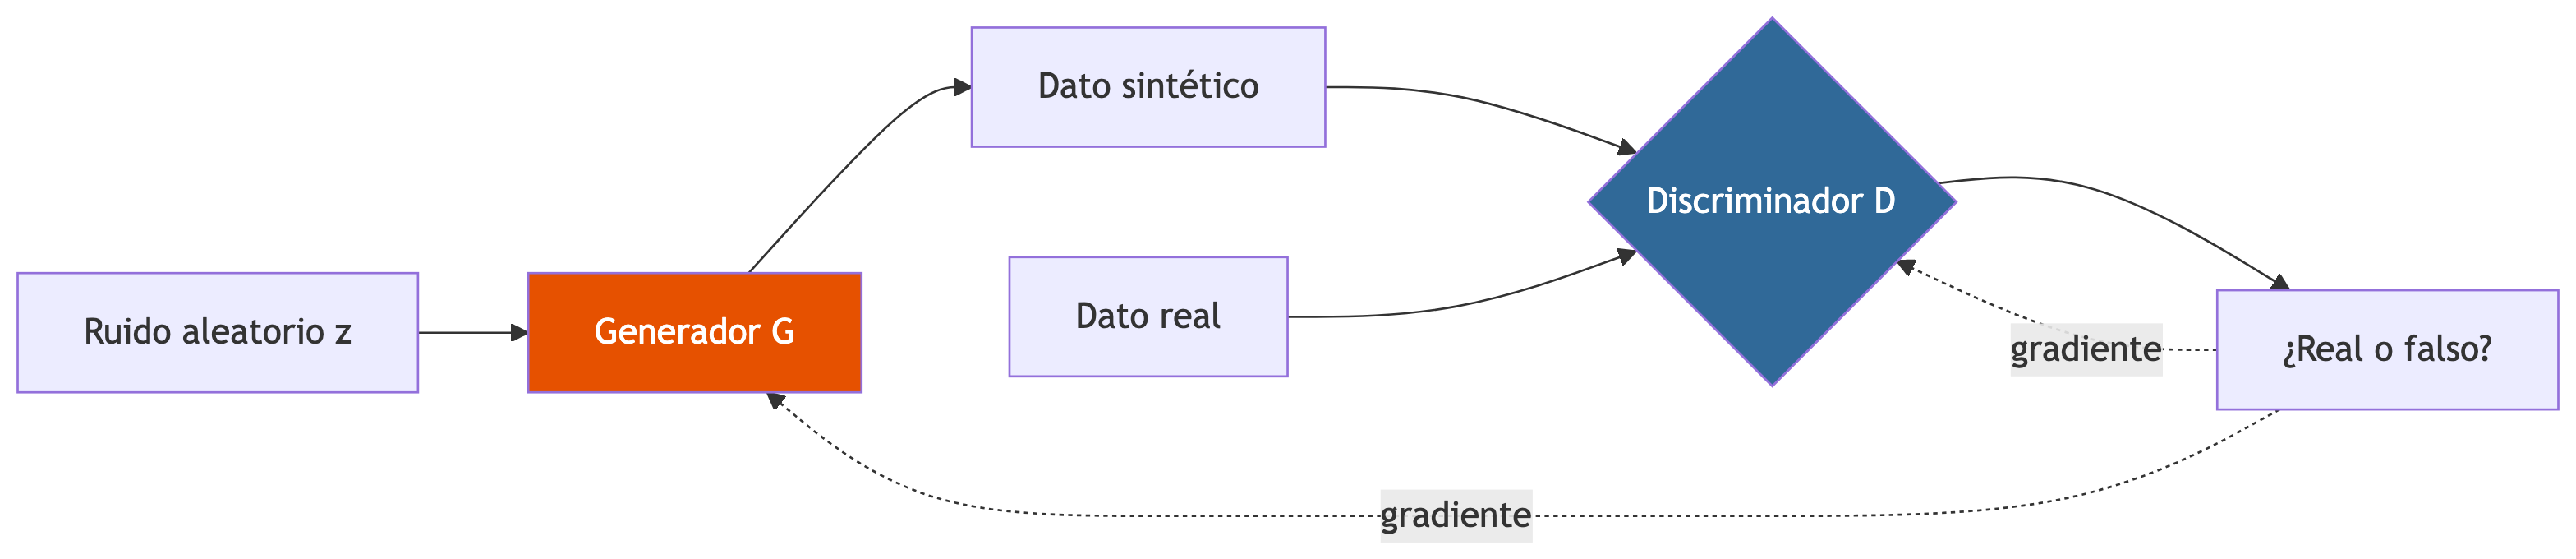

### CTGAN (Conditional Tabular GAN)

CTGAN adapta las GANs a datos tabulares resolviendo dos problemas
específicos:

1.  **Columnas mixtas (continuas + discretas):** aplica *mode-specific
    normalization* a cada columna numérica. Si una columna tiene
    distribución multimodal (ej. mezcla de salarios junior/senior), la
    normaliza por separado para cada modo.
2.  **Desequilibrio categórico:** usa *training-by-sampling*
    condicional: muestrea las categorías minoritarias con más frecuencia
    durante el entrenamiento para que el generador aprenda a
    producirlas.

In [4]:
import pandas as pd
import numpy as np

# Dataset de ejemplo: clientes de un banco
np.random.seed(42)
n = 2000

df_real = pd.DataFrame({
    "edad": np.random.normal(42, 12, n).clip(18, 75).astype(int),
    "ingresos": np.random.lognormal(10.5, 0.6, n).clip(8000, 200000).astype(int),
    "score_crediticio": np.random.normal(650, 100, n).clip(300, 850).astype(int),
    "producto": np.random.choice(["hipoteca", "tarjeta", "préstamo", "depósito"], n, p=[0.3, 0.35, 0.25, 0.1]),
    "provincia": np.random.choice(["Madrid", "Barcelona", "Valencia", "Sevilla", "Bilbao"], n, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    "target": np.random.choice([0, 1], n, p=[0.85, 0.15])  # 15% contratan producto
})

print(f"Dataset real: {df_real.shape[0]} filas, {df_real.shape[1]} columnas")
print(f"Target: {df_real['target'].value_counts().to_dict()}")
print(f"\n{df_real.head(8).to_string()}")

Dataset real: 2000 filas, 6 columnas
Target: {0: 1685, 1: 315}

   edad  ingresos  score_crediticio  producto provincia  target
0    47     24219               563   tarjeta    Madrid       0
1    40     33299               646  hipoteca  Valencia       0
2    49     22573               651   tarjeta  Valencia       1
3    60     30188               697  hipoteca    Madrid       0
4    39     11658               513  depósito    Bilbao       0
5    39     41273               709   tarjeta    Madrid       1
6    60     36341               379  hipoteca    Bilbao       0
7    51     22242               587   tarjeta   Sevilla       0

In [5]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)

synthesizer = CTGANSynthesizer(metadata, epochs=600, batch_size=100, verbose=False)
synthesizer.fit(df_real)

df_sintetico_gan = synthesizer.sample(num_rows=2000)
print(f"Datos sintéticos generados: {df_sintetico_gan.shape[0]} filas")
print(f"{df_sintetico_gan.head(8).to_string()}")

Datos sintéticos generados: 2000 filas
   edad  ingresos  score_crediticio  producto  provincia  target
0    27     41611               614  depósito  Barcelona       0
1    50     38374               536  depósito   Valencia       0
2    27     63750               774   tarjeta     Bilbao       1
3    36     39359               418   tarjeta     Madrid       0
4    44     83699               727  préstamo     Bilbao       0
5    54     69464               510  depósito     Madrid       0
6    50     25179               340   tarjeta    Sevilla       1
7    46     77898               653   tarjeta     Madrid       1

> **CopulaGAN: modelando dependencias**
>
> **CopulaGAN** es una variante de CTGAN que añade una transformación de
> cópula antes del entrenamiento. Las cópulas capturan la estructura de
> dependencia entre columnas independientemente de sus distribuciones
> marginales. Es preferible cuando las correlaciones entre columnas son
> el aspecto más importante a preservar.

------------------------------------------------------------------------

## 3. VAEs para datos tabulares (TVAE)

### Intuición: comprimir y reconstruir

Un **Variational Autoencoder (VAE)** aprende a comprimir cada fila de
datos en un vector pequeño (espacio latente) y luego a reconstruirla. La
magia está en que el espacio latente es **regular**: fuerzas a que siga
una distribución normal, lo que te permite muestrear nuevos puntos y
decodificarlos a datos sintéticos.

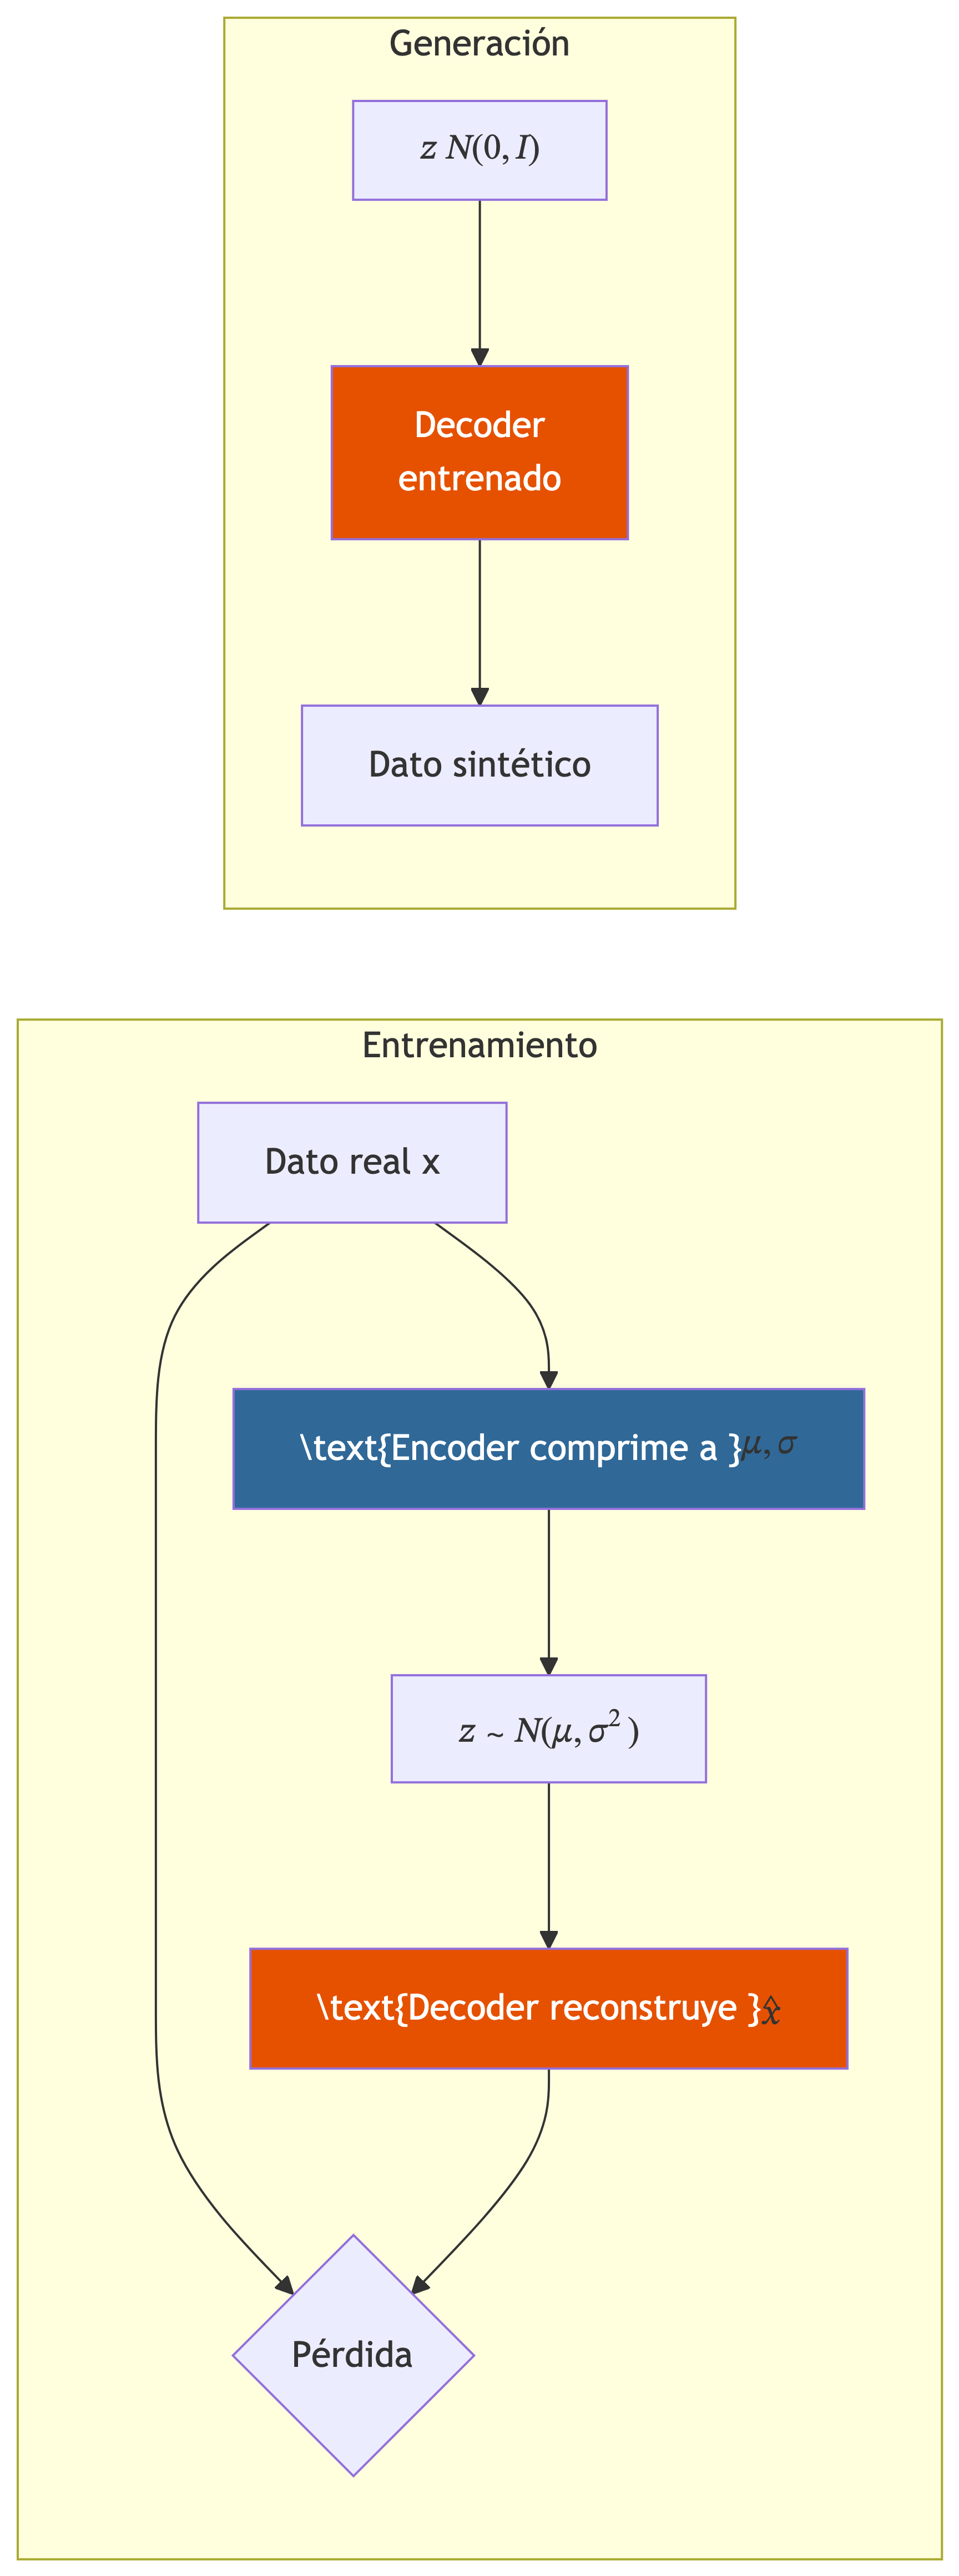

- **Encoder:** comprime `x` (fila de 10 columnas) a `z` (vector de 2-3
  dimensiones) + una varianza
- **Decoder:** reconstruye `x̂` a partir de `z`
- **Pérdida:** error de reconstrucción + KL divergence (para que `z` sea
  $~N(0,I)$)
- **Generar:** muestrea $z \sim N(0,I)$ y pásalo por el decoder

### TVAE (Tabular VAE)

TVAE aplica la misma lógica que CTGAN al preprocesamiento de datos
tabulares (mode-specific normalization para columnas continuas) pero
usando la arquitectura VAE en lugar de la adversarial.

**¿Cuándo elegir CTGAN vs. TVAE?** No hay un ganador universal. La
recomendación práctica es probar ambos (SDV lo hace trivial) y comparar
las métricas de validación.

In [6]:
from sdv.single_table import TVAESynthesizer

synthesizer_tvae = TVAESynthesizer(metadata, epochs=600, batch_size=100, verbose=False)
synthesizer_tvae.fit(df_real)

df_sintetico_vae = synthesizer_tvae.sample(num_rows=2000)
print(f"Datos sintéticos TVAE: {df_sintetico_vae.shape[0]} filas")

Datos sintéticos TVAE: 2000 filas

------------------------------------------------------------------------

## 4. Modelos de difusión para datos tabulares (TabDDPM)

### Intuición: añadir ruido y aprender a limpiarlo

Los modelos de difusión funcionan en dos fases:

1.  **Forward (difusión):** tomas un dato real $x_\theta$ y le añades
    ruido gaussiano progresivamente hasta convertirlo en ruido puro
    $x_T$.
2.  **Reverse (denoising):** entrenas una red neuronal para que aprenda
    a invertir el proceso: dado $x_t$ (parcialmente ruidoso), predecir
    $x_{t-1}$ (menos ruidoso).

Para generar datos sintéticos: partes de ruido puro y aplicas el proceso
inverso aprendido.

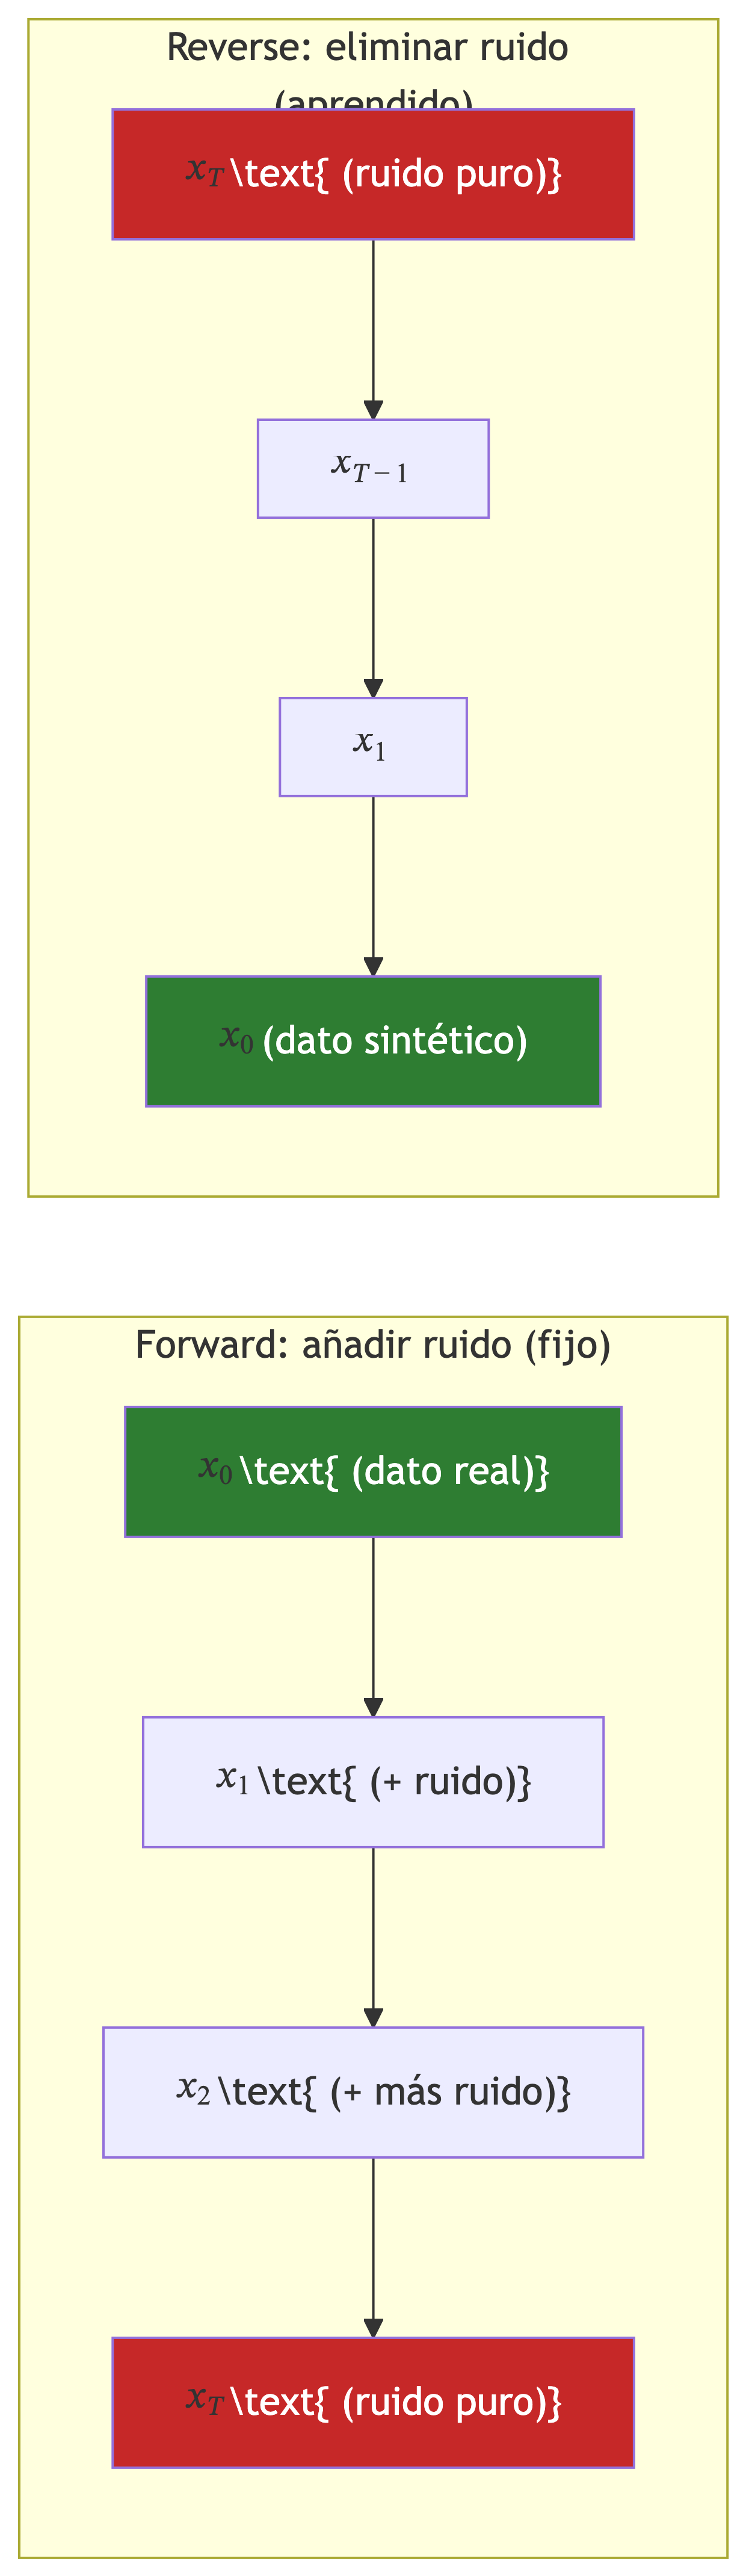

**TabDDPM** adapta este paradigma a datos tabulares combinando: - Un
modelo de difusión para columnas numéricas - Un modelo multinomial para
columnas categóricas (añadiendo ruido vía transiciones de Markov en
lugar de ruido gaussiano)

Es el enfoque más reciente y prometedor (2023), aunque
computacionalmente más costoso que CTGAN/TVAE.

> **Note**
>
> TabDDPM no está integrado en SDV (requiere implementación propia con
> PyTorch). Lo mencionamos como referencia del estado del arte y para
> entender que el ecosistema de datos sintéticos tabulares sigue
> evolucionando.

------------------------------------------------------------------------

## 5. SDV (Synthetic Data Vault): framework unificado

SDV unifica todo bajo una API común. El flujo es siempre el mismo:

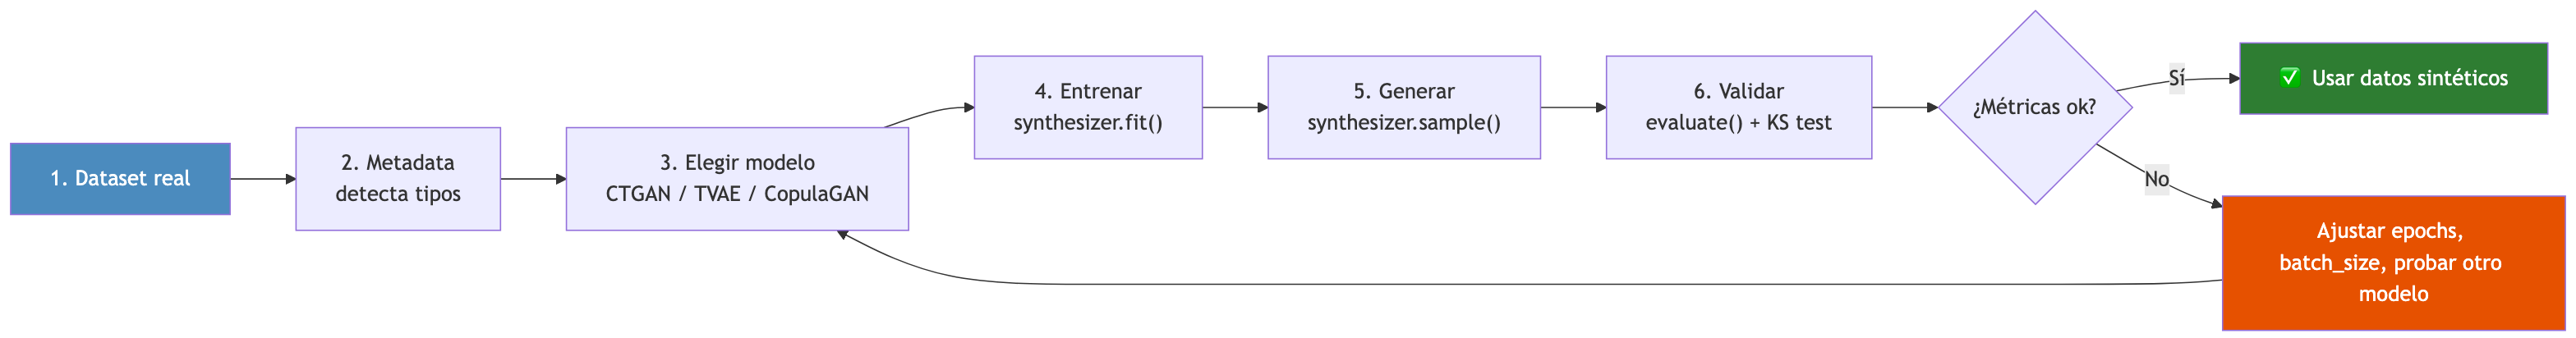

------------------------------------------------------------------------

## 6. Validación estadística

Generar datos sintéticos no basta. Hay que **demostrar** que son útiles,
fieles y seguros.

### 6.1 Fidelidad: ¿se parecen a los datos reales?

In [7]:
from scipy.stats import ks_2samp, chi2_contingency

print("=" * 60)
print("KS TEST — Variables numéricas")
print("H₀: las distribuciones real y sintética son iguales")
print("=" * 60)

resultados_ks = {}
for col in ["edad", "ingresos", "score_crediticio"]:
    stat, pval = ks_2samp(df_real[col], df_sintetico_gan[col])
    resultados_ks[col] = {"statistic": stat, "p_value": pval}
    conclusion = "✅ Se parecen (p > 0.05)" if pval > 0.05 else "❌ Difieren (p ≤ 0.05)"
    print(f"  {col:20s} | KS={stat:.4f} | p={pval:.4f} | {conclusion}")

print("\n" + "=" * 60)
print("CHI-CUADRADO — Variables categóricas")
print("H₀: las frecuencias real y sintética son iguales")
print("=" * 60)

for col in ["producto", "provincia"]:
    real_freq = df_real[col].value_counts(normalize=True)
    sint_freq = df_sintetico_gan[col].value_counts(normalize=True)
    all_cats = sorted(set(real_freq.index) | set(sint_freq.index))
    tabla = pd.DataFrame({"real": [real_freq.get(c, 0) * len(df_real) for c in all_cats],
                           "sintetico": [sint_freq.get(c, 0) * len(df_sintetico_gan) for c in all_cats]})
    chi2, pval, _, _ = chi2_contingency(tabla)
    conclusion = "✅ Se parecen (p > 0.05)" if pval > 0.05 else "❌ Difieren (p ≤ 0.05)"
    print(f"  {col:20s} | χ²={chi2:.2f} | p={pval:.4f} | {conclusion}")

KS TEST — Variables numéricas
H₀: las distribuciones real y sintética son iguales
  edad                 | KS=0.0755 | p=0.0000 | ❌ Difieren (p ≤ 0.05)
  ingresos             | KS=0.2875 | p=0.0000 | ❌ Difieren (p ≤ 0.05)
  score_crediticio     | KS=0.1040 | p=0.0000 | ❌ Difieren (p ≤ 0.05)

CHI-CUADRADO — Variables categóricas
H₀: las frecuencias real y sintética son iguales
  producto             | χ²=109.35 | p=0.0000 | ❌ Difieren (p ≤ 0.05)
  provincia            | χ²=44.05 | p=0.0000 | ❌ Difieren (p ≤ 0.05)

### 6.2 Utilidad: ¿sirven para entrenar un modelo?

La prueba definitiva: entrenar un clasificador con datos sintéticos y
evaluarlo con datos reales.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_real = df_real.drop("target", axis=1)
y_real = df_real["target"]
X_gan = df_sintetico_gan.drop("target", axis=1)
y_gan = df_sintetico_gan["target"].round().astype(int).clip(0, 1)

X_real_enc = pd.get_dummies(X_real, columns=["producto", "provincia"])
X_gan_enc = pd.get_dummies(X_gan, columns=["producto", "provincia"])
X_gan_enc = X_gan_enc.reindex(columns=X_real_enc.columns, fill_value=0)

X_train_r, X_test, y_train_r, y_test = train_test_split(X_real_enc, y_real, test_size=0.3, random_state=42)

rf_real = RandomForestClassifier(n_estimators=100, random_state=42)
rf_real.fit(X_train_r, y_train_r)
f1_real = classification_report(y_test, rf_real.predict(X_test), output_dict=True)["macro avg"]["f1-score"]

rf_gan = RandomForestClassifier(n_estimators=100, random_state=42)
rf_gan.fit(X_gan_enc, y_gan)
f1_gan = classification_report(y_test, rf_gan.predict(X_test), output_dict=True)["macro avg"]["f1-score"]

print(f"F1 (modelo entrenado con datos REALES):      {f1_real:.4f}")
print(f"F1 (modelo entrenado con datos SINTÉTICOS):  {f1_gan:.4f}")
print(f"Diferencia:                                  {f1_real - f1_gan:.4f}")

F1 (modelo entrenado con datos REALES):      0.4889
F1 (modelo entrenado con datos SINTÉTICOS):  0.4882
Diferencia:                                  0.0006

### 6.3 Visualización: PCA del espacio de features

Proyectar datos reales y sintéticos a 2 dimensiones con PCA y visualizar
el solapamiento.

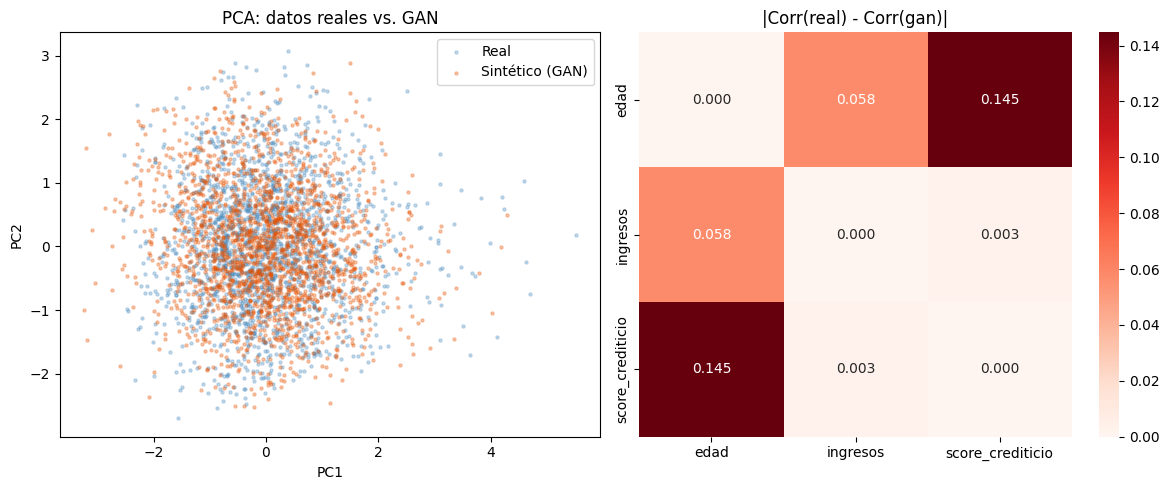

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_real_scaled = StandardScaler().fit_transform(X_real.select_dtypes(include=[np.number]))
X_gan_scaled = StandardScaler().fit_transform(X_gan.select_dtypes(include=[np.number]).reindex(columns=X_real.select_dtypes(include=[np.number]).columns, fill_value=0))

pca = PCA(n_components=2)
real_pca = pca.fit_transform(X_real_scaled)
gan_pca = pca.transform(X_gan_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.3, s=5, label="Real", color="#4B8BBE")
axes[0].scatter(gan_pca[:, 0], gan_pca[:, 1], alpha=0.3, s=5, label="Sintético (GAN)", color="#e65100")
axes[0].set_title("PCA: datos reales vs. GAN")
axes[0].legend()
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Heatmap de diferencia de correlaciones
corr_real = X_real.select_dtypes(include=[np.number]).corr()
corr_gan = X_gan.select_dtypes(include=[np.number]).corr()
diff_corr = (corr_real - corr_gan).abs()

sns.heatmap(diff_corr, annot=True, fmt=".3f", cmap="Reds", ax=axes[1])
axes[1].set_title("|Corr(real) - Corr(gan)|")

plt.tight_layout()
plt.show()

------------------------------------------------------------------------

## 7. Criterios de decisión

| Criterio | Prompting LLM | SDV (CTGAN/TVAE) | TabDDPM |
|------------------|------------------|------------------|------------------|
| **Setup** | Minutos | Minutos | Horas |
| **Requiere GPU** | No | Recomendada | Sí |
| **Correlaciones entre columnas** | Débil | Fuerte | Muy fuerte |
| **Tamaño mínimo del dataset** | 10-50 filas (few-shot) | 1000+ filas | 5000+ filas |
| **Privacidad diferencial** | No disponible | ε configurable en SDV | Experimental |
| **Datos mixtos (num + cat)** | Regular | Excelente | Excelente |
| **Interpretabilidad** | Alta (ves el prompt) | Baja (caja negra) | Muy baja |
| **Casos de uso típicos** | Prototipos, testing, datos textuales | Producción, oversampling, anonimización | Investigación, máxima fidelidad |

> **Regla práctica**
>
> 1.  **¿Necesitas algo ya?** → Prompting LLM. En 5 minutos tienes
>     datos.
> 2.  **¿Calidad estadística?** → SDV con CTGAN/TVAE. Entrena, valida,
>     itera.
> 3.  **¿Máxima fidelidad?** → Evalúa TabDDPM si tienes GPU y tiempo.
> 4.  **¿Privacidad?** → SDV con `epsilon` parameter. Ver Bloque 4.

------------------------------------------------------------------------

## Referencias del tema

- Xu, L. et al. (2019). *Modeling Tabular Data using Conditional GAN*
  (CTGAN). NeurIPS 2019.
  [arXiv:1907.00503](https://arxiv.org/abs/1907.00503)
- Patki, N. et al. (2016). *The Synthetic Data Vault*. IEEE DSAA 2016.
  [PDF](https://dai.lids.mit.edu/wp-content/uploads/2018/03/SDV.pdf)
- Kotelnikov, A. et al. (2023). *TabDDPM: Modelling Tabular Data with
  Diffusion Models*. ICML 2023.
  [arXiv:2209.15421](https://arxiv.org/abs/2209.15421)
- Xu, L. & Veeramachaneni, K. (2018). *Synthesizing Tabular Data using
  Generative Adversarial Networks*.
  [arXiv:1811.11264](https://arxiv.org/abs/1811.11264)
- Goodfellow, I. et al. (2014). *Generative Adversarial Nets*.
  NeurIPS 2014. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)
- Kingma, D. & Welling, M. (2013). *Auto-Encoding Variational Bayes*.
  ICLR 2014. [arXiv:1312.6114](https://arxiv.org/abs/1312.6114)

------------------------------------------------------------------------

> Continúa con la validación práctica en los **[ejercicios de datos
> sintéticos](../evaluables/hpd4-datos-sinteticos.qmd)**.